LIBRARIES

In [84]:
# Set seed for reproducibility
SEED = 37

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
# Import PyTorch utilities for data handling
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import StratifiedKFold

torch.manual_seed(SEED)
from torch import nn

!pip install optuna
import optuna
from optuna.trial import TrialState


if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
#%matplotlib inline


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
PyTorch version: 2.9.0+cu128
Device: cuda


Data Loading and Exploration

In [85]:
# Load data
X_train = pd.read_csv('Data/pirate_pain_train.csv')
y_train = pd.read_csv('Data/pirate_pain_train_labels.csv')

X_test = pd.read_csv('Data/pirate_pain_test.csv')

In [86]:
# Check if there are any missing values in the datasets
print("Missing values in training data:", X_train.isnull().sum().sum())

Missing values in training data: 0


In [87]:
# Print the shape of the datasets
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (105760, 40)
Training labels shape: (661, 2)
Test data shape: (211840, 40)


In [88]:
# Print the first few rows of the training data
X_train.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.499558e-06,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.976952e-07,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.533820e-07,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.006865e-05,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.437266e-06,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5


In [89]:
y_train.head()

,sample_index,label
0,0,no_pain
1,1,no_pain
2,2,low_pain
3,3,no_pain
4,4,no_pain


In [90]:
# print the number of unique classes in the labels
print("Number of unique classes in labels:", y_train['label'].nunique())

Number of unique classes in labels: 3


In [91]:
X_train.describe()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
count,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,...,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,1.057600e+05,105760.000000,105760.000000,105760.000000,105760.000000,105760.0
mean,330.000000,79.500000,1.633746,1.654851,1.653640,1.663134,0.943095,0.916955,0.779296,0.767921,...,3.972126e-05,4.176794e-05,3.561780e-05,3.138109e-05,1.024604e-04,0.041905,0.058244,0.049886,0.062273,0.5
std,190.814948,46.187338,0.682423,0.669639,0.666649,0.661994,0.202051,0.197608,0.295605,0.300787,...,4.974496e-03,5.472244e-03,1.235450e-03,4.062914e-04,3.206128e-03,0.060293,0.079819,0.060773,0.072597,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001015,0.005403,...,0.000000e+00,1.510494e-07,0.000000e+00,1.063144e-08,0.000000e+00,0.000203,0.000000,0.000000,0.000000,0.5
25%,165.000000,39.750000,2.000000,2.000000,2.000000,2.000000,0.828277,0.811445,0.568850,0.520020,...,6.545878e-08,3.321650e-07,3.275038e-07,2.841805e-07,7.161332e-07,0.009885,0.012652,0.016290,0.019638,0.5
50%,330.000000,79.500000,2.000000,2.000000,2.000000,2.000000,1.005126,0.979468,0.909549,0.914834,...,8.302747e-07,1.095971e-06,1.024209e-06,8.746147e-07,3.126723e-06,0.021898,0.031739,0.031843,0.039041,0.5
75%,495.000000,119.250000,2.000000,2.000000,2.000000,2.000000,1.081039,1.056611,0.995187,0.994324,...,2.800090e-06,3.079465e-06,3.021830e-06,2.507548e-06,9.946107e-06,0.048579,0.071051,0.058741,0.079518,0.5
max,660.000000,159.000000,2.000000,2.000000,2.000000,2.000000,1.407968,1.334613,1.306046,1.254729,...,1.442198e+00,1.305001e+00,2.742411e-01,3.643074e-02,9.473540e-01,1.223617,1.187419,1.412037,1.370765,0.5


In [92]:
# Drop the last column
X_train = X_train.drop(columns=['joint_30'])

In [93]:
# Count the number of unique users
print("Number of unique users:", X_train['sample_index'].nunique())

Number of unique users: 661


In [94]:
# Create custom maps for the categorical features
legs_custom_map = {
    'one+peg_leg': 1,
    'two': 2
}
hands_custom_map = {
    'one+hook_hand': 1,
    'two': 2
}
eyes_custom_map = {
    'one+eye_patch': 1,
    'two': 2
}
class_labels_map = {
    'no_pain' : 0,
    'low_pain' : 1,
    'high_pain' : 2
}

# Apply the custom maps to the categorical features and labels
X_train['n_legs'] = X_train['n_legs'].map(legs_custom_map)
X_train['n_hands'] = X_train['n_hands'].map(hands_custom_map)
X_train['n_eyes'] = X_train['n_eyes'].map(eyes_custom_map)
y_train['label'] = y_train['label'].map(class_labels_map)

In [95]:
X_train.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_20,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29
0,0,0,2,0,2,1,2,2,2,1.094705,...,6.140248e-07,3.499558e-06,1.945042e-06,0.000004,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815
1,0,1,2,2,2,2,2,2,2,1.135183,...,1.931978e-06,3.976952e-07,6.765107e-07,0.000006,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716
2,0,2,2,0,2,2,2,2,2,1.080745,...,5.730838e-07,1.533820e-07,1.698525e-07,0.000001,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105
3,0,3,2,2,2,2,2,2,2,0.938017,...,3.677486e-05,1.006865e-05,5.511079e-07,0.000002,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648
4,0,4,2,2,2,2,2,2,2,1.090185,...,2.037939e-05,4.437266e-06,1.735459e-07,0.000002,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328


Data Preprocessing and Splitting

In [96]:
# Check the distribution of labels
print("Label distribution:\n", y_train['label'].value_counts())

Label distribution:
 label
0    511
1     94
2     56
Name: count, dtype: int64


In [97]:
# Check the length of the time series for each user
print("Length of time series for each user:")
time_series_lengths = X_train.groupby('sample_index').size()
print(time_series_lengths)

Length of time series for each user:
sample_index
0      160
1      160
2      160
3      160
4      160
      ... 
656    160
657    160
658    160
659    160
660    160
Length: 661, dtype: int64


In [98]:
# Define the window size
WINDOW_SIZE = 80

# Define the stride for overlapping windows
STRIDE = 20

In [99]:
# Define constants for model architecture
input_shape = (WINDOW_SIZE, 30)  # 30 features (joints)
num_classes = 3  # no_pain, low_pain, high_pain

In [100]:
# Define a function to build sequences from the dataset
def build_sequences(x_df, y_df, window=200, stride=200):
    # Sanity check to ensure the window is divisible by the stride
    assert window % stride == 0

    # Initialize lists to store sequences and their corresponding labels
    dataset = []
    labels = []

    # Iterate over unique IDs in the DataFrame
    for id in x_df['sample_index'].unique():
        # Extract sensor data for the current sample ID
        temp = x_df[x_df['sample_index'] == id][['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09',
    'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20',
    'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29']].values

        # Retrieve the label for the current sample ID
        label = y_df[y_df['sample_index'] == id]['label'].values[0]

        # Calculate padding length to ensure full windows
        padding_len = window - len(temp) % window

        # Set padding length to zero to avoid adding an unnecessary full window of zeros in case len(temp) % window == 0
        if padding_len == window and len(temp) % window == 0:
             padding_len = 0

        # Determine the number of features (30 in this case)
        num_features = temp.shape[1]

        # Create zero padding and concatenate with the data
        padding = np.zeros((padding_len, num_features), dtype='float32')
        temp = np.concatenate((temp, padding))

        # Build feature windows and associate them with labels
        idx = 0
        while idx + window <= len(temp):
            dataset.append(temp[idx:idx + window])
            labels.append(label)
            idx += stride

    # Convert lists to numpy arrays for further processing
    dataset = np.array(dataset)
    labels = np.array(labels)

    return dataset, labels

In [101]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Determine the optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [102]:
# Calculate class weights based on inverse frequency
class_counts = y_train['label'].value_counts().sort_index()
total_samples = len(y_train)

# Compute weights: total / (num_classes * count_per_class)
class_weights = total_samples / (num_classes * class_counts.values)

# Convert to tensor
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("\nClass distribution:")
print(class_counts)
print("\nClass weights:")
for i, weight in enumerate(class_weights):
    print(f"Class {i}: {weight:.4f}")


Class distribution:
label
0    511
1     94
2     56
Name: count, dtype: int64

Class weights:
Class 0: 0.4312
Class 1: 2.3440
Class 2: 3.9345


Model Building and Summary

In [103]:
def recurrent_summary(model, input_size):
    """
    Custom summary function that emulates torchinfo's output while correctly
    counting parameters for RNN/GRU/LSTM layers.

    This function is designed for models whose direct children are
    nn.Linear, nn.RNN, nn.GRU, or nn.LSTM layers.

    Args:
        model (nn.Module): The model to analyze.
        input_size (tuple): Shape of the input tensor (e.g., (seq_len, features)).
    """

    # Dictionary to store output shapes captured by forward hooks
    output_shapes = {}
    # List to track hook handles for later removal
    hooks = []

    def get_hook(name):
        """Factory function to create a forward hook for a specific module."""
        def hook(module, input, output):
            # Handle RNN layer outputs (returns a tuple)
            if isinstance(output, tuple):
                # output[0]: all hidden states with shape (batch, seq_len, hidden*directions)
                shape1 = list(output[0].shape)
                shape1[0] = -1  # Replace the batch dimension with -1

                # output[1]: final hidden state h_n (or tuple (h_n, c_n) for LSTM)
                if isinstance(output[1], tuple):  # LSTM case: (h_n, c_n)
                    shape2 = list(output[1][0].shape)  # Extract h_n only
                else:  # RNN/GRU case: h_n only
                    shape2 = list(output[1].shape)

                # Replace the batch dimension (middle position) with -1
                shape2[1] = -1

                output_shapes[name] = f"[{shape1}, {shape2}]"

            # Handle standard layer outputs (e.g., Linear)
            else:
                shape = list(output.shape)
                shape[0] = -1  # Replace the batch dimension with -1
                output_shapes[name] = f"{shape}"
        return hook

    # 1. Determine the device where model parameters reside
    try:
        device = next(model.parameters()).device
    except StopIteration:
        device = torch.device("cpu")  # Fallback for models without parameters

    # 2. Create a dummy input tensor with batch_size=1
    dummy_input = torch.randn(1, *input_size).to(device)

    # 3. Register forward hooks on target layers
    # Iterate through direct children of the model (e.g., self.rnn, self.classifier)
    for name, module in model.named_children():
        if isinstance(module, (nn.Linear, nn.RNN, nn.GRU, nn.LSTM)):
            # Register the hook and store its handle for cleanup
            hook_handle = module.register_forward_hook(get_hook(name))
            hooks.append(hook_handle)

    # 4. Execute a dummy forward pass in evaluation mode
    model.eval()
    with torch.no_grad():
        try:
            model(dummy_input)
        except Exception as e:
            print(f"Error during dummy forward pass: {e}")
            # Clean up hooks even if an error occurs
            for h in hooks:
                h.remove()
            return

    # 5. Remove all registered hooks
    for h in hooks:
        h.remove()

    # --- 6. Print the summary table ---

    print("-" * 79)
    # Column headers
    print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
    print("=" * 79)

    total_params = 0
    total_trainable_params = 0

    # Iterate through modules again to collect and display parameter information
    for name, module in model.named_children():
        if name in output_shapes:
            # Count total and trainable parameters for this module
            module_params = sum(p.numel() for p in module.parameters())
            trainable_params = sum(p.numel() for p in module.parameters() if p.requires_grad)

            total_params += module_params
            total_trainable_params += trainable_params

            # Format strings for display
            layer_name = f"{name} ({type(module).__name__})"
            output_shape_str = str(output_shapes[name])
            params_str = f"{trainable_params:,}"

            print(f"{layer_name:<25} {output_shape_str:<28} {params_str:<15}")

    print("=" * 79)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {total_trainable_params:,}")
    print(f"Non-trainable params: {total_params - total_trainable_params:,}")
    print("-" * 79)

In [104]:
class RecurrentClassifier(nn.Module):
    """
    Generic RNN classifier (RNN, LSTM, GRU).
    Uses the last hidden state for classification.
    """
    def __init__(
            self,
            input_size,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='GRU',        # 'RNN', 'LSTM', or 'GRU'
            bidirectional=False,
            dropout_rate=0.2
            ):
        super().__init__()

        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional

        # Map string name to PyTorch RNN class
        rnn_map = {
            'RNN': nn.RNN,
            'LSTM': nn.LSTM,
            'GRU': nn.GRU
        }

        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")

        rnn_module = rnn_map[rnn_type]

        # Dropout is only applied between layers (if num_layers > 1)
        dropout_val = dropout_rate if num_layers > 1 else 0

        # Create the recurrent layer
        self.rnn = rnn_module(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       # Input shape: (batch, seq_len, features)
            bidirectional=bidirectional,
            dropout=dropout_val
        )

        # Calculate input size for the final classifier
        if self.bidirectional:
            classifier_input_size = hidden_size * 2 # Concat fwd + bwd
        else:
            classifier_input_size = hidden_size

        # Final classification layer
        self.classifier = nn.Linear(classifier_input_size, num_classes)

    def forward(self, x):
        """
        x shape: (batch_size, seq_length, input_size)
        """

        # rnn_out shape: (batch_size, seq_len, hidden_size * num_directions)
        rnn_out, hidden = self.rnn(x)

        # LSTM returns (h_n, c_n), but we only need h_n
        if self.rnn_type == 'LSTM':
            hidden = hidden[0]

        # hidden shape: (num_layers * num_directions, batch_size, hidden_size)

        if self.bidirectional:
            # Reshape to (num_layers, 2, batch_size, hidden_size)
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_size)

            # Concat last fwd (hidden[-1, 0, ...]) and bwd (hidden[-1, 1, ...])
            # Final shape: (batch_size, hidden_size * 2)
            hidden_to_classify = torch.cat([hidden[-1, 0, :, :], hidden[-1, 1, :, :]], dim=1)
        else:
            # Take the last layer's hidden state
            # Final shape: (batch_size, hidden_size)
            hidden_to_classify = hidden[-1]

        # Get logits
        logits = self.classifier(hidden_to_classify)
        return logits


# Create the model and display architecture with parameter count
rnn_model = RecurrentClassifier(
    input_size=input_shape[-1], # Pass the number of features
    hidden_size=128,
    num_layers=2,
    num_classes=num_classes,
    dropout_rate=0.,
    rnn_type='RNN'
    ).to(device)
recurrent_summary(rnn_model, input_size=input_shape)

-------------------------------------------------------------------------------
Layer (type)              Output Shape                 Param #           
rnn (RNN)                 [[-1, 80, 128], [2, -1, 128]] 53,504         
classifier (Linear)       [-1, 3]                      387            
Total params: 53,891
Trainable params: 53,891
Non-trainable params: 0
-------------------------------------------------------------------------------


Network Architecture and Training Hyperparameters

In [105]:
# Define the window size
WINDOW_SIZE = 50

# Define the stride for overlapping windows
STRIDE = 5

# Hyperparameters
OPTUNA_ENABLED = False

# Define the batch size
BATCH_SIZE = 128

# Training configuration
LEARNING_RATE = 0.00039841012615803484#1e-3
EPOCHS = 500
PATIENCE = 50
N_FOLDS = 5

# Architecture
HIDDEN_LAYERS = 2 # Hidden layers
HIDDEN_SIZE = 128 # Neurons per layer
BIDIRECTIONAL = True

# Regularization
DROPOUT_RATE = 0.2237148610906678 # Dropout probability
L1_LAMBDA = 2.1713099523410197e-05 # L1 penalty
L2_LAMBDA = 5.191066820725292e-05 # L2 penalty

In [106]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

Model Training

In [107]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [108]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):
    """
    Perform one complete training epoch through the entire training dataset.

    Args:
        model (nn.Module): The neural network model to train
        train_loader (DataLoader): PyTorch DataLoader containing training data batches
        criterion (nn.Module): Loss function (e.g., CrossEntropyLoss, MSELoss)
        optimizer (torch.optim): Optimization algorithm (e.g., Adam, SGD)
        scaler (GradScaler): PyTorch's gradient scaler for mixed precision training
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)
        l1_lambda (float): Lambda for L1 regularization
        l2_lambda (float): Lambda for L2 regularization

    Returns:
        tuple: (average_loss, f1 score) - Training loss and f1 score for this epoch
    """
    model.train()  # Set the model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from the previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm


        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

In [109]:
def validate_one_epoch(model, val_loader, criterion, device):
    """
    Perform one complete validation epoch through the entire validation dataset.

    Args:
        model (nn.Module): The neural network model to evaluate (must be in eval mode)
        val_loader (DataLoader): PyTorch DataLoader containing validation data batches
        criterion (nn.Module): Loss function used to calculate validation loss
        device (torch.device): Computing device ('cuda' for GPU, 'cpu' for CPU)

    Returns:
        tuple: (average_loss, accuracy) - Validation loss and accuracy for this epoch

    Note:
        This function automatically sets the model to evaluation mode and disables
        gradient computation for efficiency during validation.
    """
    model.eval()  # Set the model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [110]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):
    """
    Train the neural network model on the training data and validate on the validation data.
    """

    # Define the directory for saving models if it doesn't exist yet'
    MODEL_DIR = "models"

    if not os.path.exists(MODEL_DIR):
        os.makedirs(MODEL_DIR, exist_ok=True)
        print(f"Created directory: {MODEL_DIR}")

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0 and val_loader:  # Only enable if we have patience AND a val_loader
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # --- Training ---
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )
        training_history['train_loss'].append(train_loss)
        training_history['train_f1'].append(train_f1)

        # --- Validation & Early Stopping (Only if val_loader is provided) ---
        if val_loader:
            val_loss, val_f1 = validate_one_epoch(
                model, val_loader, criterion, device
            )
            training_history['val_loss'].append(val_loss)
            training_history['val_f1'].append(val_f1)

            # Print progress every N epochs or on the first epoch
            if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
                print(f"Epoch {epoch:3d}/{epochs} | "
                      f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                      f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

            # Early stopping logic
            if patience > 0:
                current_metric = training_history[evaluation_metric][-1]
                is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

                if is_improvement:
                    best_metric = current_metric
                    best_epoch = epoch
                    torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                    patience_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= patience:
                        print(f"Early stopping triggered after {epoch} epochs.")
                        break

        # --- No Validation (Full Dataset Training) ---
        else:
            training_history['val_loss'].append(None)
            training_history['val_f1'].append(None)
            # Just print training progress
            if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
                print(f"Epoch {epoch:3d}/{epochs} | "
                      f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f}")

    # --- Post-Training ---

    # Restore the best model weights if early stopping was used
    if restore_best_weights and patience > 0 and val_loader:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save the final model if no early stopping (or no validation loader)
    # This will save the model at the end of the final epoch (e.g., best_epoch)
    if patience == 0 or not val_loader:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

In [111]:
# Optuna objective function
def objective(trial):
    # Suggest hyperparameters
    lr = trial.suggest_float('lr', 1e-4, 1e-3, log=True)
    hidden_size = 128
    hidden_layers = 1
    dropout_rate = trial.suggest_float('dropout_rate', 0., 0.3)
    l1_lambda = trial.suggest_float('l1_lambda', 1e-6, 1e-3, log=True)
    l2_lambda = trial.suggest_float('l2_lambda', 1e-6, 1e-3, log=True)

    all_fold_f1 = []
    scale_columns = [f'joint_{i:02d}' for i in range(30)]

    # K-Fold Cross-Validation
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    # Get unique users and their labels (one label per user)
    unique_users = X_train['sample_index'].unique()
    user_labels = []
    for user in unique_users:
        label = y_train[y_train['sample_index'] == user]['label'].iloc[0]
        user_labels.append(label)

    user_labels = np.array(user_labels)

    # Perform K-Fold Cross-Validation
    for fold, (train_idx, val_idx) in enumerate(skf.split(unique_users, user_labels), 1):
        # Split users
        train_users = unique_users[train_idx]
        val_users = unique_users[val_idx]

        # Split data
        df_train_data = X_train[X_train['sample_index'].isin(train_users)].copy()
        df_train_labels = y_train[y_train['sample_index'].isin(train_users)].copy()
        df_val_data = X_train[X_train['sample_index'].isin(val_users)].copy()
        df_val_labels = y_train[y_train['sample_index'].isin(val_users)].copy()

        # Normalize
        scaler = StandardScaler()
        scaler.fit(df_train_data[scale_columns])
        df_train_data[scale_columns] = scaler.transform(df_train_data[scale_columns])
        df_val_data[scale_columns] = scaler.transform(df_val_data[scale_columns])

        # Build sequences
        X_train_seq, y_train_seq = build_sequences(df_train_data, df_train_labels, WINDOW_SIZE, STRIDE)
        X_val_seq, y_val_seq = build_sequences(df_val_data, df_val_labels, WINDOW_SIZE, WINDOW_SIZE)

        # Create loaders
        train_ds = TensorDataset(
            torch.from_numpy(X_train_seq).float(),
            torch.from_numpy(y_train_seq).long()
        )
        val_ds = TensorDataset(
            torch.from_numpy(X_val_seq).float(),
            torch.from_numpy(y_val_seq).long()
        )

        train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True, drop_last=True)
        val_loader = make_loader(val_ds, BATCH_SIZE, shuffle=False, drop_last=False)

        # Calculate fold-specific class weights
        fold_class_counts = pd.Series(y_train_seq).value_counts().sort_index()
        fold_class_weights = len(y_train_seq) / (num_classes * fold_class_counts.values)
        class_weights_fold = torch.FloatTensor(fold_class_weights).to(device)

        # Create model
        model = RecurrentClassifier(
            input_size=input_shape[-1],
            hidden_size=hidden_size,
            num_layers=hidden_layers,
            num_classes=num_classes,
            dropout_rate=dropout_rate,
            bidirectional=BIDIRECTIONAL,
            rnn_type='GRU'
        ).to(device)

        # Setup training
        criterion_fold = nn.CrossEntropyLoss(weight=class_weights_fold)
        optimizer_fold = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=l2_lambda)
        scaler_fold = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

        # Train (reduced epochs for tuning)
        model, fold_history = fit(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=300,
            criterion=criterion_fold,
            optimizer=optimizer_fold,
            scaler=scaler_fold,
            device=device,
            l1_lambda=l1_lambda,
            l2_lambda=0,  # Already in optimizer
            patience=30,
            verbose=0,
            experiment_name=f"optuna_trial{trial.number}_fold{fold}"
        )

        # Get best F1
        best_val_f1 = np.max(fold_history['val_f1'])
        all_fold_f1.append(best_val_f1)

        # Pruning
        trial.report(np.mean(all_fold_f1), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(all_fold_f1)

In [112]:
if OPTUNA_ENABLED:
    # Run hyperparameter optimization
    print("Starting Optuna hyperparameter optimization...")
    study = optuna.create_study(
        direction="maximize",
        study_name="GRU_Pain_Classification",
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=2)
    )

    study.optimize(objective, n_trials=100, show_progress_bar=True)

    print("\n" + "="*60)
    print("OPTIMIZATION COMPLETE")
    print("="*60)
    print(f"Best Mean F1: {study.best_value:.4f}")
    print("\nBest Hyperparameters:")
    for key, value in study.best_params.items():
        print(f"  {key}: {value}")
    print("="*60)

In [113]:
if OPTUNA_ENABLED:
    # Apply optimized hyperparameters
    LEARNING_RATE = study.best_params['lr']
    HIDDEN_SIZE = study.best_params['hidden_size']
    HIDDEN_LAYERS = 2
    DROPOUT_RATE = study.best_params['dropout_rate']
    L1_LAMBDA = study.best_params['l1_lambda']
    L2_LAMBDA = study.best_params['l2_lambda']

    print("\nUpdated hyperparameters for final training:")
    print(f"Learning Rate: {LEARNING_RATE:.6f}")
    print(f"Hidden Size: {HIDDEN_SIZE}")
    print(f"Hidden Layers: {HIDDEN_LAYERS}")
    print(f"Dropout Rate: {DROPOUT_RATE:.4f}")
    print(f"L1 Lambda: {L1_LAMBDA:.6f}")
    print(f"L2 Lambda: {L2_LAMBDA:.6f}")

In [114]:
# Prepare for k-fold cross-validation
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Get unique users and their labels (one label per user)
unique_users = X_train['sample_index'].unique()
user_labels = []
for user in unique_users:
    label = y_train[y_train['sample_index'] == user]['label'].iloc[0]
    user_labels.append(label)

user_labels = np.array(user_labels)

# Store results for each fold
fold_results = []
scale_columns = [f'joint_{i:02d}' for i in range(30)]

for fold, (train_idx, val_idx) in enumerate(skf.split(unique_users, user_labels), 1):
    print(f"\n{'='*50}")
    print(f"Final Training Fold {fold}/{N_FOLDS} with optimized hyperparameters:")
    print(f"{'='*50}")

    # Split users
    train_users = unique_users[train_idx]
    val_users = unique_users[val_idx]

    # Split data
    df_train_data = X_train[X_train['sample_index'].isin(train_users)].copy()
    df_train_labels = y_train[y_train['sample_index'].isin(train_users)].copy()
    df_val_data = X_train[X_train['sample_index'].isin(val_users)].copy()
    df_val_labels = y_train[y_train['sample_index'].isin(val_users)].copy()

    # Check label distribution
    print(f"Training set label distribution:\n{df_train_labels['label'].value_counts().sort_index()}")
    print(f"Validation set label distribution:\n{df_val_labels['label'].value_counts().sort_index()}")

    # Normalize data
    scaler = StandardScaler()
    scaler.fit(df_train_data[scale_columns])

    # Transform both train and val data
    df_train_data[scale_columns] = scaler.transform(df_train_data[scale_columns])
    df_val_data[scale_columns] = scaler.transform(df_val_data[scale_columns])

    # Build sequences
    X_train_seq, y_train_seq = build_sequences(df_train_data, df_train_labels, WINDOW_SIZE, STRIDE)
    X_val_seq, y_val_seq = build_sequences(df_val_data, df_val_labels, WINDOW_SIZE, STRIDE)

    # Create tensors and loaders
    X_train_tensor = torch.from_numpy(X_train_seq).to(torch.float32)
    X_val_tensor = torch.from_numpy(X_val_seq).to(torch.float32)
    y_train_tensor = torch.from_numpy(y_train_seq).to(torch.long)
    y_val_tensor = torch.from_numpy(y_val_seq).to(torch.long)

    train_ds = TensorDataset(X_train_tensor, y_train_tensor)
    val_ds = TensorDataset(X_val_tensor, y_val_tensor)

    train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
    val_loader = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

    # Create a fresh model for this fold
    model = RecurrentClassifier(
        input_size=input_shape[-1],
        hidden_size=HIDDEN_SIZE,
        num_layers=HIDDEN_LAYERS,
        num_classes=num_classes,
        dropout_rate=DROPOUT_RATE,
        bidirectional=BIDIRECTIONAL,
        rnn_type='GRU'
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)
    scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

    # Train the model
    model, history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=EPOCHS,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=device,
        l1_lambda=L1_LAMBDA,
        l2_lambda=L2_LAMBDA,
        verbose=10,
        experiment_name=f"gru_fold{fold}",
        patience=PATIENCE
    )

    # Store results
    fold_results.append({
    'fold': fold,
    'val_f1': history['val_f1'][-1],
    'val_loss': history['val_loss'][-1],
    'model': model,
    'history': history,  # Store full training history
    'val_loader': val_loader  # Store validation loader for evaluation
    })

    print(f"Fold {fold} - Val F1: {history['val_f1'][-1]:.4f}")

# Calculate average performance across folds
avg_f1 = np.mean([r['val_f1'] for r in fold_results])
std_f1 = np.std([r['val_f1'] for r in fold_results])
print(f"\n{'='*50}")
print(f"Cross-Validation Results:")
print(f"Average F1: {avg_f1:.4f} ± {std_f1:.4f}")
print(f"{'='*50}")


Final Training Fold 1/5 with optimized hyperparameters:
Training set label distribution:
label
0    408
1     76
2     44
Name: count, dtype: int64
Validation set label distribution:
label
0    103
1     18
2     12
Name: count, dtype: int64
Training 500 epochs...
Epoch   1/500 | Train: Loss=1.1132, F1 Score=0.7027 | Val: Loss=0.6602, F1 Score=0.7892
Epoch  10/500 | Train: Loss=0.2458, F1 Score=0.9655 | Val: Loss=0.4959, F1 Score=0.9073
Epoch  20/500 | Train: Loss=0.1670, F1 Score=0.9847 | Val: Loss=0.5682, F1 Score=0.9253
Epoch  30/500 | Train: Loss=0.1395, F1 Score=0.9908 | Val: Loss=0.5128, F1 Score=0.9327
Epoch  40/500 | Train: Loss=0.1098, F1 Score=0.9938 | Val: Loss=0.5459, F1 Score=0.9333
Epoch  50/500 | Train: Loss=0.1378, F1 Score=0.9784 | Val: Loss=0.6392, F1 Score=0.9058
Epoch  60/500 | Train: Loss=0.1133, F1 Score=0.9882 | Val: Loss=0.4338, F1 Score=0.9412
Epoch  70/500 | Train: Loss=0.0806, F1 Score=0.9949 | Val: Loss=0.4885, F1 Score=0.9397
Epoch  80/500 | Train: Loss=0.

In [115]:
# Display results for each fold
print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS")
print("="*60)

for result in fold_results:
    print(f"Fold {result['fold']}: Val F1 = {result['val_f1']:.4f}, Val Loss = {result['val_loss']:.4f}")

# Calculate statistics
avg_f1 = np.mean([r['val_f1'] for r in fold_results])
std_f1 = np.std([r['val_f1'] for r in fold_results])
avg_loss = np.mean([r['val_loss'] for r in fold_results])
std_loss = np.std([r['val_loss'] for r in fold_results])

print(f"\nAverage Val F1: {avg_f1:.4f} ± {std_f1:.4f}")
print(f"Average Val Loss: {avg_loss:.4f} ± {std_loss:.4f}")
print("="*60)


CROSS-VALIDATION RESULTS
Fold 1: Val F1 = 0.9098, Val Loss = 0.6660
Fold 2: Val F1 = 0.9060, Val Loss = 0.9051
Fold 3: Val F1 = 0.9355, Val Loss = 0.8367
Fold 4: Val F1 = 0.9294, Val Loss = 0.5762
Fold 5: Val F1 = 0.9255, Val Loss = 0.8532

Average Val F1: 0.9212 ± 0.0114
Average Val Loss: 0.7674 ± 0.1249


In [ ]:
# Select the best fold based on validation F1 score
best_fold_idx = np.argmax([r['val_f1'] for r in fold_results])
best_fold = fold_results[best_fold_idx]
best_model = best_fold['model']

print(f"\nBest fold: {best_fold['fold']} with Val F1 = {best_fold['val_f1']:.4f}")

In [122]:
# Print the mean train F1 score over the best models
mean_train_f1 = np.mean([np.max(result['history']['train_f1']) for result in fold_results])
print(f"\nMean of best training F1 scores across folds: {mean_train_f1:.4f}")


Mean of best training F1 scores across folds: 0.9992


In [121]:
# Print the best fold val f1 score for each fold
print("\nBest validation F1 score per fold:")
for i, result in enumerate(fold_results, 1):
    best_f1 = np.max(result['history']['val_f1'])
    print(f"Fold {i}: Best val F1 = {best_f1:.4f}")

# Print the mean of all the best fold val f1 scores
best_f1_scores = [np.max(result['history']['val_f1']) for result in fold_results]
mean_best_f1 = np.mean(best_f1_scores)
print(f"\nMean of best validation F1 scores across folds: {mean_best_f1:.4f}")


Best validation F1 score per fold:
Fold 1: Best val F1 = 0.9577
Fold 2: Best val F1 = 0.9120
Fold 3: Best val F1 = 0.9407
Fold 4: Best val F1 = 0.9304
Fold 5: Best val F1 = 0.9488

Mean of best validation F1 scores across folds: 0.9379


In [117]:
# 1) Normalize test features (reuse your scaler)
full_scaler = StandardScaler()
full_scaler.fit(X_train[scale_columns])
X_test_normalized = X_test.copy()
X_test_normalized[scale_columns] = full_scaler.transform(X_test[scale_columns])

# Keep only the 30 joint feature columns the model was trained on
# THIS IS THE CORRECTED LINE:
feature_columns = scale_columns

# 2) Build windows per sample_index (no crossing between samples)
per_sample_windows = []
per_sample_map = []
unique_samples = X_test_normalized['sample_index'].unique()

for sid in unique_samples:
    grp = X_test_normalized[X_test_normalized['sample_index'] == sid].reset_index(drop=True)
    # This line now correctly selects only the 30 joint features
    grp_features = grp[feature_columns].apply(pd.to_numeric, errors='coerce').fillna(0.0).values.astype(np.float32)
    n = len(grp_features)

    if n >= WINDOW_SIZE:
        for start in range(0, n - WINDOW_SIZE + 1, STRIDE):
            window = grp_features[start:start + WINDOW_SIZE]
            per_sample_windows.append(window)
            per_sample_map.append(sid)
    else:
        # Too short → pad with the last row
        pad_count = max(0, WINDOW_SIZE - n)
        pad_rows = np.repeat(grp_features[-1:, :], pad_count, axis=0)
        window = np.vstack([grp_features, pad_rows])
        per_sample_windows.append(window)
        per_sample_map.append(sid)

# Convert to a proper numeric array
X_test_seq = np.stack(per_sample_windows).astype(np.float32)
print(f"Built {len(X_test_seq)} windows for {len(unique_samples)} unique samples.")

X_test_tensor = torch.from_numpy(X_test_seq).to(torch.float32)
test_ds = TensorDataset(X_test_tensor, torch.zeros(len(X_test_tensor)))
test_loader = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# 3) Load top-5 folds (you already computed top_5_folds earlier). Ensemble: average logits
print("\nGenerating ensemble predictions (averaging logits across top-5 models)...")
all_logits = []

# Sort the folds by validation F1 score in descending order
top_folds = sorted(fold_results, key=lambda x: x['val_f1'], reverse=True)

# Select the top N_FOLDS folds
top_5_folds = top_folds[:N_FOLDS]

for fold in top_5_folds:
    model = fold['model']
    model.eval()
    fold_logits = []
    with torch.no_grad():
        for inputs, _ in test_loader:
            inputs = inputs.to(device)
            # This call will now succeed as inputs.shape[-1] is 30
            logits = model(inputs)           # expected shape: (batch, num_classes)
            fold_logits.append(logits.cpu())
    fold_logits = torch.cat(fold_logits, dim=0)      # (num_windows, num_classes)
    all_logits.append(fold_logits)

# Average logits across models
avg_logits = torch.stack(all_logits).mean(dim=0)     # (num_windows, num_classes)
window_predictions = avg_logits.argmax(dim=1).numpy()  # (num_windows,)

# 4) Build DataFrame mapping windows back to sample_index
temp_results = pd.DataFrame({
    'sample_index': per_sample_map,
    'prediction': window_predictions
})

# 5) Aggregate per sample_index (majority vote). Tie-breaker: first mode.
def majority_vote(series):
    modes = series.mode()
    return modes.iloc[0]  # if it's a tie, pandas.mode returns sorted modes; pick first

final_submission = temp_results.groupby('sample_index')['prediction'].agg(majority_vote).reset_index()

# 6) Map to labels and format sample_index
reverse_class_map = {0: 'no_pain', 1: 'low_pain', 2: 'high_pain'}
final_submission['label'] = final_submission['prediction'].map(reverse_class_map)

ensemble_submission = final_submission[['sample_index', 'label']].copy()

# If sample_index are integers and you want zero-padded 3-digit strings:
try:
    ensemble_submission['sample_index'] = ensemble_submission['sample_index'].astype(int).apply(lambda x: f"{x:03d}")
except Exception:
    # fallback: keep the original formatting
    ensemble_submission['sample_index'] = ensemble_submission['sample_index'].astype(str)

# 7) Save and report
ensemble_submission.to_csv('ensemble_submission.csv', index=False)
print(f"\nEnsemble submission created with {len(ensemble_submission)} predictions (one per original sample).")
print("First few ensemble predictions:")
print(ensemble_submission.head(10))

Built 30452 windows for 1324 unique samples.

Generating ensemble predictions (averaging logits across top-5 models)...

Ensemble submission created with 1324 predictions (one per original sample).
First few ensemble predictions:
  sample_index    label
0          000  no_pain
1          001  no_pain
2          002  no_pain
3          003  no_pain
4          004  no_pain
5          005  no_pain
6          006  no_pain
7          007  no_pain
8          008  no_pain
9          009  no_pain


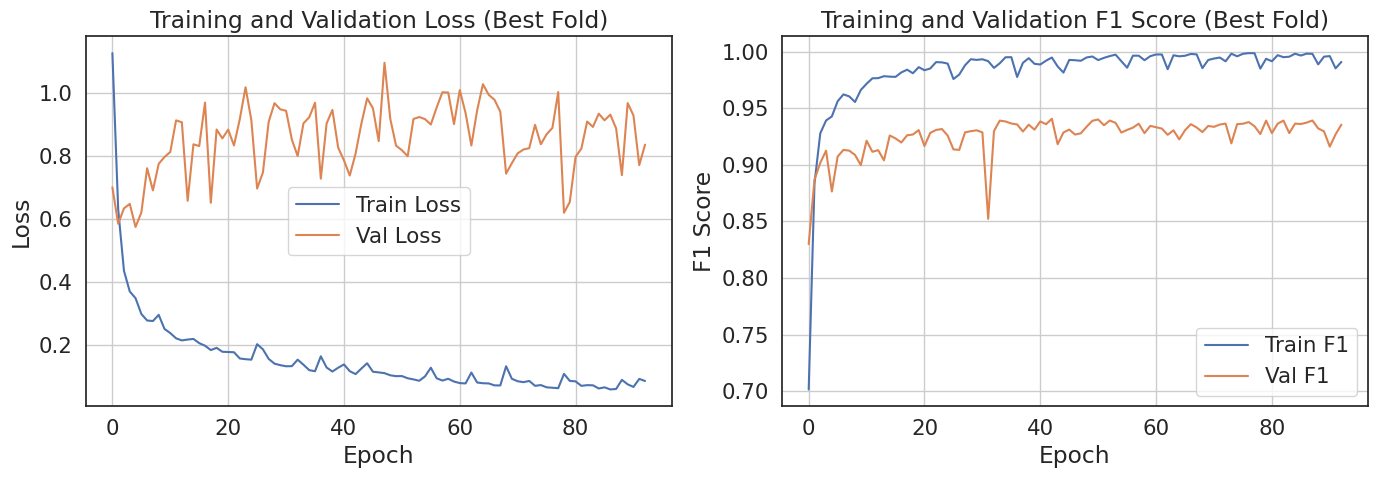

In [118]:
# Plot loss curves
plt.figure(figsize=(14, 5))

# Get the history from the best fold
best_history = best_fold['history']

plt.subplot(1, 2, 1)
plt.plot(best_history['train_loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss (Best Fold)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(best_history['train_f1'], label='Train F1')
plt.plot(best_history['val_f1'], label='Val F1')
plt.title('Training and Validation F1 Score (Best Fold)')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [119]:
# Recreate the validation data for the best fold
# You'll need to store val_loader in fold_results during cross-validation

# Get predictions
best_model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for inputs, targets in best_fold['val_loader']:  # Need to save this in fold_results
        inputs = inputs.to(device)
        logits = best_model(inputs)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

y_true = np.concatenate(all_targets)
y_pred = np.concatenate(all_predictions)

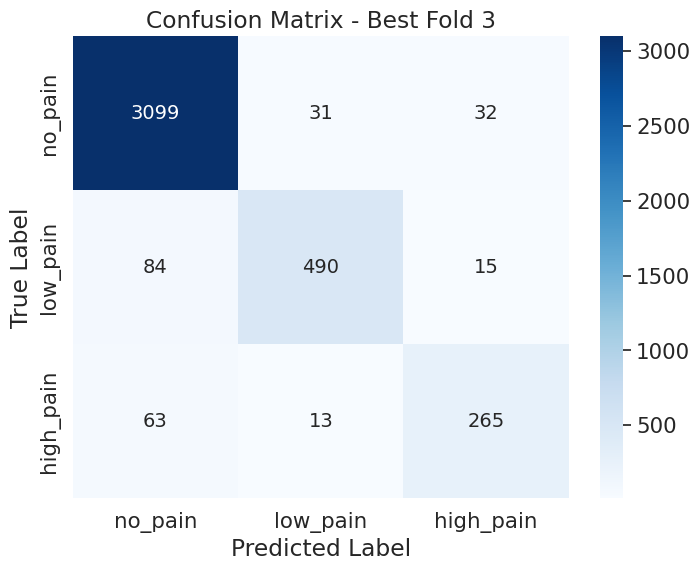


Classification Metrics:
Accuracy: 0.9418
F1 Score (weighted): 0.9407
Precision (weighted): 0.9406
Recall (weighted): 0.9418


In [120]:
# Calculate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['no_pain', 'low_pain', 'high_pain'],
            yticklabels=['no_pain', 'low_pain', 'high_pain'])
plt.title(f'Confusion Matrix - Best Fold {best_fold["fold"]}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print classification metrics
print("\nClassification Metrics:")
print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"F1 Score (weighted): {f1_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Precision (weighted): {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_true, y_pred, average='weighted'):.4f}")